<a href="https://colab.research.google.com/github/loki-gif/case_study/blob/main/supervised_learning_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROBLEM OVERVIEW

Customer churn refers to the situation where customers stop using a company's services. In the telecommunications industry, retaining existing customers is often more cost-effective than acquiring new ones. Therefore, predicting which customers are likely to churn helps the company take proactive measures, such as offering discounts, personalized plans, or improved customer support, to retain valuable customers.

In this project, historical customer demographic information, service usage details, billing information, and contract details are used to build a machine learning model that predicts whether a customer will churn. The target variable is Churn, which is a binary classification problem with two possible outcomes: Yes (customer leaves) or No (customer stays).

## Objectives

The main objectives of this project are:

- Develop a machine learning model to accurately predict customer churn.
- Analyze customer demographics, service usage, contract types, and billing information to identify the factors influencing customer churn.
- Perform data preprocessing, including handling missing values, encoding categorical variables, and scaling numerical features where necessary.
- Train and evaluate multiple machine learning classification algorithms to determine the best-performing model.
- Compare model performance using evaluation metrics such as **Accuracy, Precision, Recall, F1-score, and ROC-AUC**.
- Identify the most important features contributing to customer churn.
- Provide actionable insights that help the telecommunications company implement effective customer retention strategies and reduce customer attrition.

In [709]:
import pandas as pd
import numpy as np

In [710]:
train = pd.read_csv('/content/Training_data.csv')
train

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,5649-RXQTV,Male,0,No,No,51,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,3908-MKIMJ,Male,1,Yes,No,68,No,No phone service,DSL,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,4277-BWBML,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,NaN,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.3,No


In [711]:
test = pd.read_csv('/content/Testing_data.csv')
test

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,2039-JONDJ,Male,0,No,No,27,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),55.45,1477.65,No
1405,2516-VQRRV,Female,1,No,No,2,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,75.45,158.4,Yes
1406,5570-PTWEH,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes
1407,1722-LDZJS,Male,0,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.20,1068.15,No


In [712]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [713]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [714]:
train = train.drop(columns = ['customerID'])
test = test.drop(columns = ['customerID'])

In [715]:
train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')
test['TotalCharges'] = pd.to_numeric(test['TotalCharges'], errors='coerce')

In [716]:
train.shape

(5634, 20)

In [717]:
train.drop_duplicates(inplace = True)
test.drop_duplicates(inplace = True)

In [718]:
train.shape

(5626, 20)

In [719]:
train.isna().sum()

,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


In [720]:
test.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


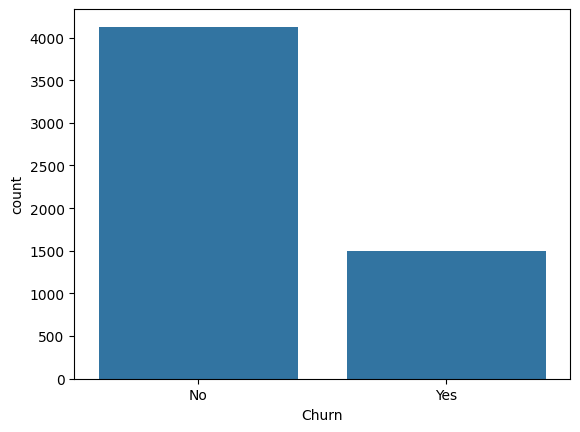

In [721]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=train, x='Churn')
plt.show()

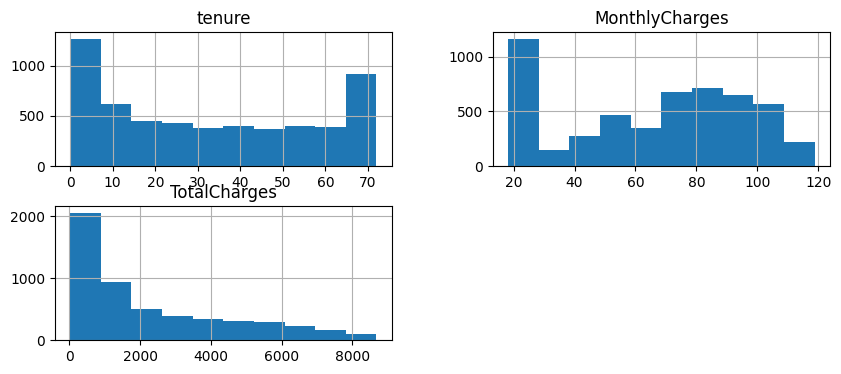

In [722]:
num_cols=['tenure','MonthlyCharges','TotalCharges']

train[num_cols].hist(figsize=(10,4))
plt.show()

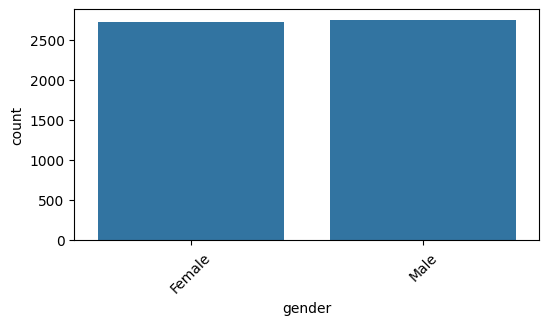

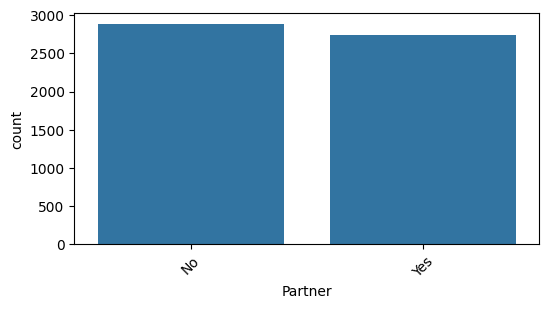

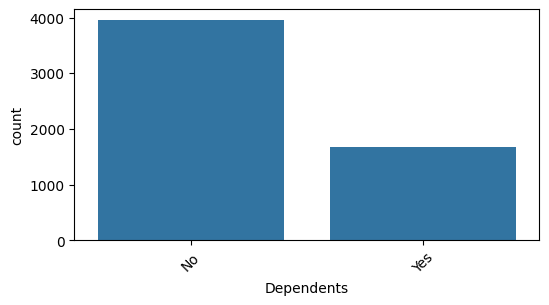

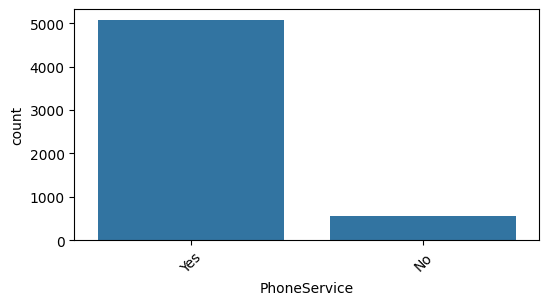

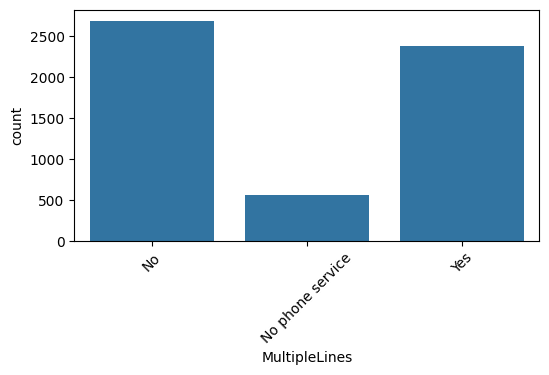

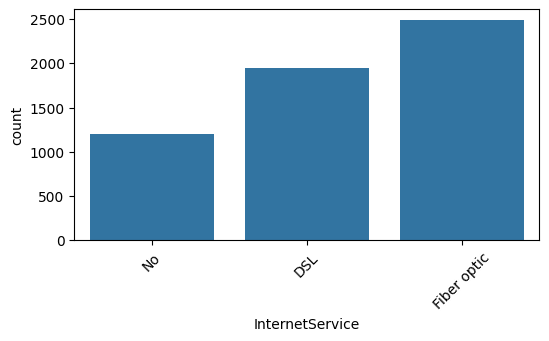

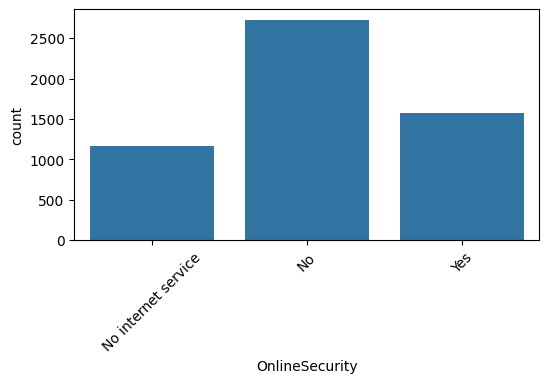

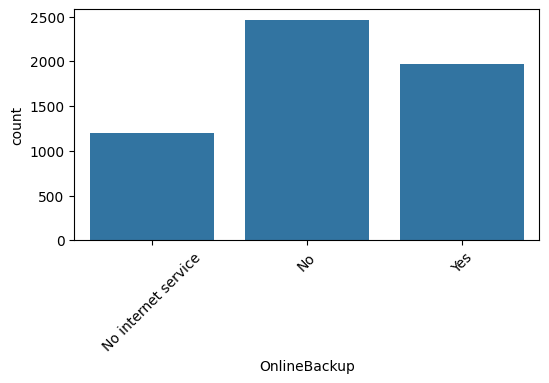

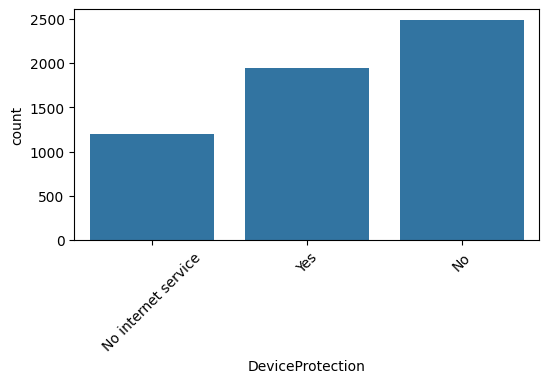

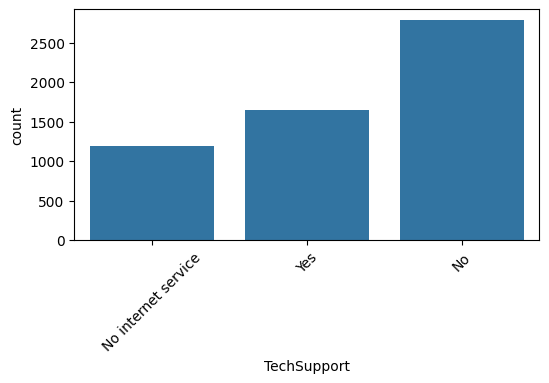

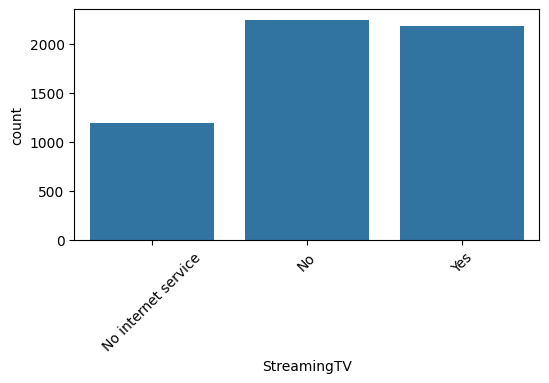

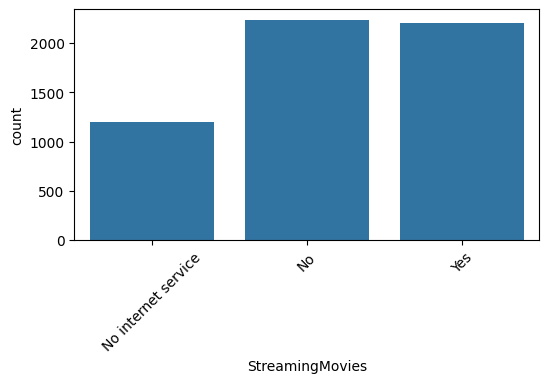

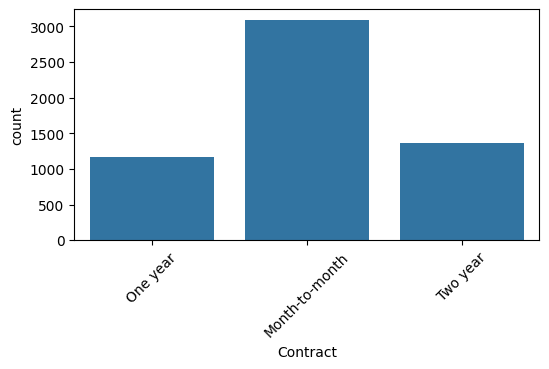

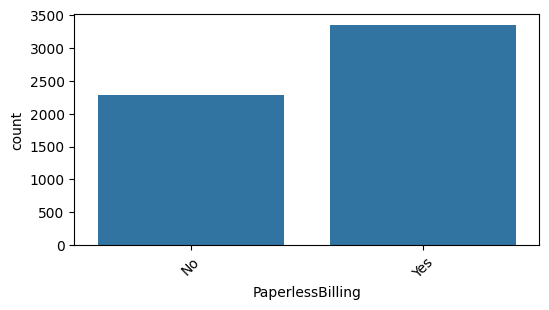

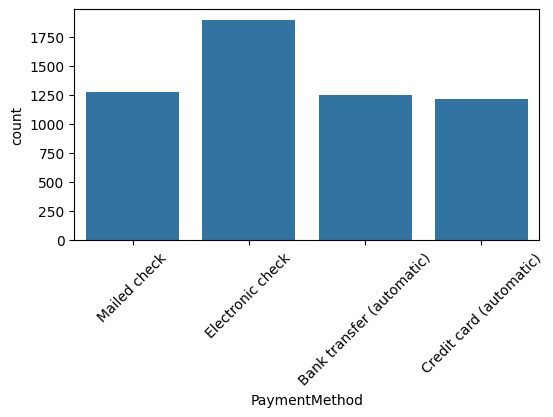

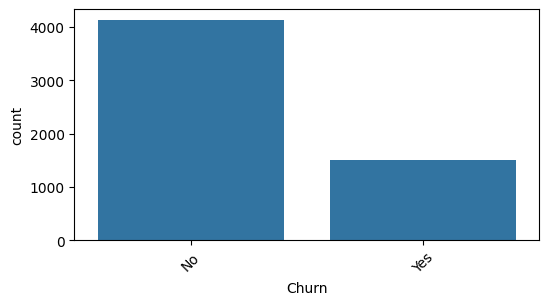

In [723]:
cat_cols=train.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=train,x=col)
    plt.xticks(rotation=45)
    plt.show()

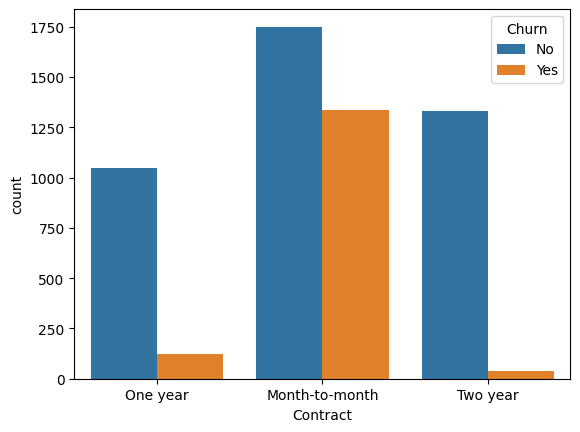

In [724]:
sns.countplot(data=train,x='Contract',hue='Churn')
plt.show()

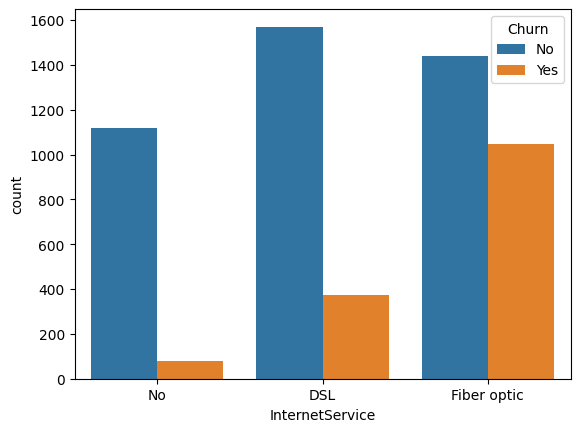

In [725]:
sns.countplot(data=train,x='InternetService',hue='Churn')
plt.show()

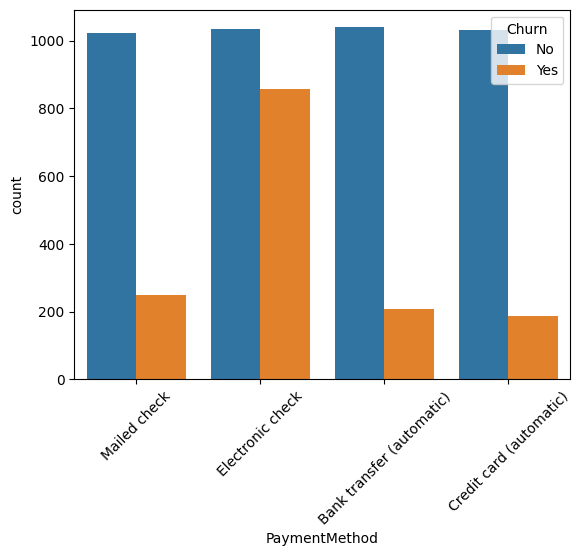

In [726]:
sns.countplot(data=train,x='PaymentMethod',hue='Churn')
plt.xticks(rotation=45)
plt.show()

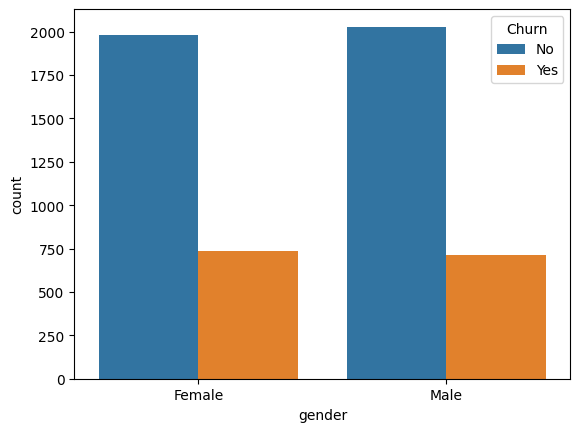

In [727]:
sns.countplot(data=train,x='gender',hue='Churn')
plt.show()

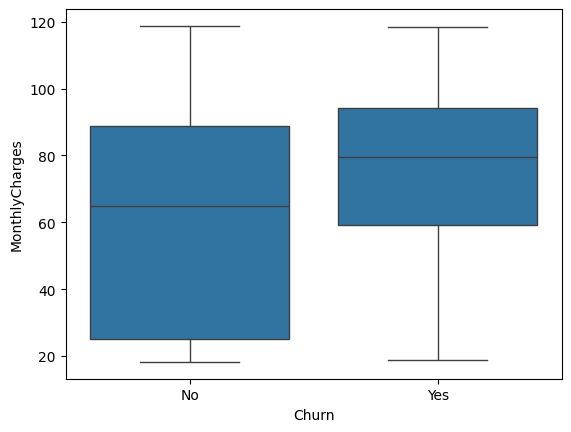

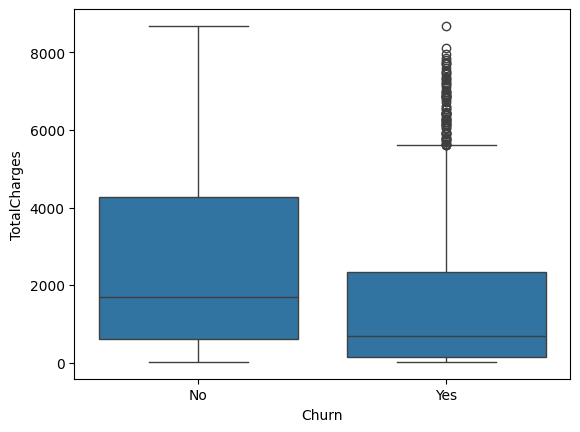

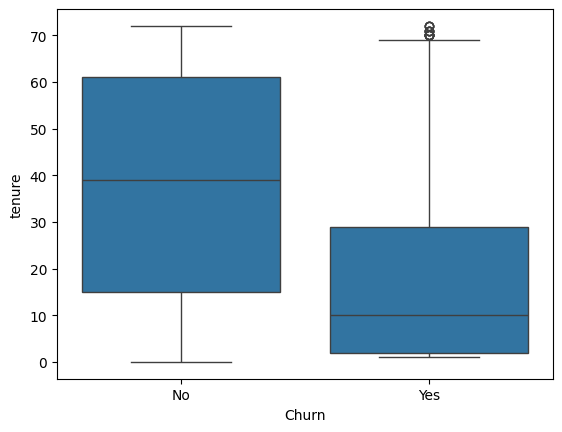

In [728]:
sns.boxplot(data=train,x='Churn',y='MonthlyCharges')
plt.show()

sns.boxplot(data=train,x='Churn',y='TotalCharges')
plt.show()

sns.boxplot(data=train,x='Churn',y='tenure')
plt.show()


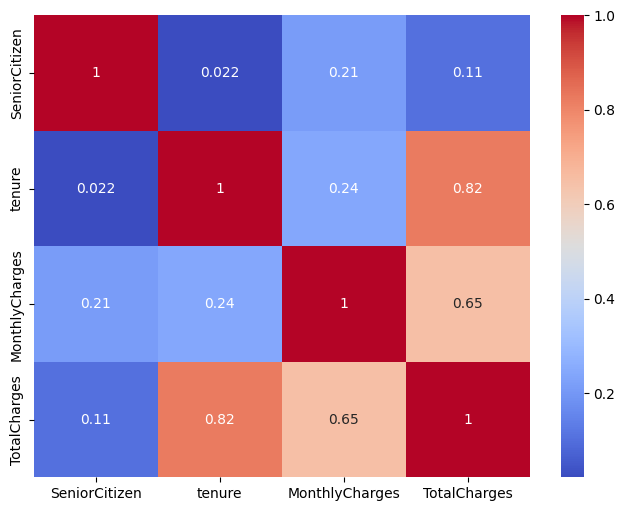

In [729]:
corr=train.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [730]:
train['gender']=train['gender'].fillna(train['gender'].mode()[0])

In [731]:
train['OnlineSecurity'] = train['OnlineSecurity'].fillna(train['OnlineSecurity'].mode()[0])

In [732]:
train[['MonthlyCharges', 'TotalCharges']].skew()

,0
MonthlyCharges,-0.238177
TotalCharges,0.964956


In [733]:
train['MonthlyCharges'] = train['MonthlyCharges'].fillna(train['MonthlyCharges'].mean())
train['TotalCharges'] = train['TotalCharges'].fillna(train['TotalCharges'].median())

In [734]:
train.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [735]:
test[['TotalCharges']].skew()

,0
TotalCharges,0.991306


In [736]:
test['TotalCharges'] = test['TotalCharges'].fillna(test['TotalCharges'].median())

In [737]:
num_cols1 = train[['tenure','MonthlyCharges','TotalCharges']]
for i in num_cols1 :
  Q1 = train[i].quantile(0.25)
  Q3 = train[i].quantile(0.75)
  IQR = Q3-Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = train[(train[i] < lower) | (train[i] > upper)]
  print(f"{i} : ")
  print(f"lower : {lower}")
  print(f"upper : {upper}")
  print(f"{len(outliers)} outliers")
  print()

tenure : 
lower : -61.5
upper : 126.5
0 outliers

MonthlyCharges : 
lower : -23.58125000000001
upper : 156.76875
0 outliers

TotalCharges : 
lower : -4275.30625
upper : 8326.84375
22 outliers



In [738]:
Q1 = train['TotalCharges'].quantile(0.25)
Q3 = train['TotalCharges'].quantile(0.75)
IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

train['TotalCharges'] = train['TotalCharges'].clip(lower,upper)

In [739]:
num_cols2 = test[['tenure','MonthlyCharges','TotalCharges']]
for i in num_cols2 :
  Q1 = test[i].quantile(0.25)
  Q3 = test[i].quantile(0.75)
  IQR = Q3-Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = test[(test[i] < lower) | (test[i] > upper)]
  print(f"{i} : ")
  print(f"lower : {lower}")
  print(f"upper : {upper}")
  print(f"{len(outliers)} outliers")
  print()

tenure : 
lower : -61.0
upper : 123.0
0 outliers

MonthlyCharges : 
lower : -58.812500000000014
upper : 178.4875
0 outliers

TotalCharges : 
lower : -4597.912499999999
upper : 8645.587499999998
0 outliers



In [740]:
train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,Female,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,Male,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,Male,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,Female,0,Yes,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Male,0,No,No,51,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,Male,1,Yes,No,68,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,Male,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,Female,0,No,No,69,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [741]:
# Binary columns
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

# Gender
train['gender'] = train['gender'].map({'Male':1, 'Female':0})
test['gender'] = test['gender'].map({'Male':1, 'Female':0})

# Yes/No columns
for col in binary_cols[1:]:
    train[col] = train[col].map({'Yes':1, 'No':0})
    test[col] = test[col].map({'Yes':1, 'No':0})

In [742]:
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

train = pd.get_dummies(train, columns=multi_cols, drop_first=True, dtype=int)
test = pd.get_dummies(test, columns=multi_cols, drop_first=True, dtype=int)

In [743]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

In [744]:
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,0.095450,1,0,-1.532842,-0.695686,0,...,0,1,0,1,0,1,0,0,0,1
1,0,0,0,0,-0.189087,0,1,-1.015010,-0.577843,0,...,1,0,0,0,0,0,0,0,0,1
2,1,0,0,0,0.949060,1,0,1.154708,1.508352,0,...,0,0,1,0,1,0,0,0,1,0
3,1,0,1,0,0.258043,1,1,-1.543199,-0.655246,0,...,0,1,0,1,0,0,1,0,0,0
4,0,0,1,1,0.420635,0,1,-0.479916,-0.040359,0,...,1,0,1,0,0,1,0,0,0,0


In [745]:
test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,0.298691,1,1,0.554023,0.474772,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,1,0,-0.839456,1,0,0.472896,-0.616070,0,...,0,0,1,0,1,1,0,0,1,0
2,1,0,0,0,0.420635,1,1,1.203039,0.889897,1,...,1,0,1,0,1,1,0,0,1,0
3,1,0,0,0,1.599430,1,1,1.831343,2.847818,0,...,1,0,1,0,1,0,1,0,1,0
4,0,0,0,0,-0.920753,0,0,-0.997749,-0.843108,0,...,1,0,0,0,0,0,0,0,1,0


In [746]:
y_train = train['Churn']
x_train = train.drop(columns = ['Churn'])

In [747]:
y_test = test['Churn']
x_test = test.drop(columns = ['Churn'])

In [748]:
x_train.shape

(5626, 30)

In [749]:
x_test.shape

(1407, 30)

In [750]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(x_train,y_train)
y_pred_lr = log_model.predict(x_test)
y_pred_lr

array([0, 0, 0, ..., 1, 0, 0])

In [751]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report
accuracy_score(y_test,y_pred_lr)

0.820184790334044

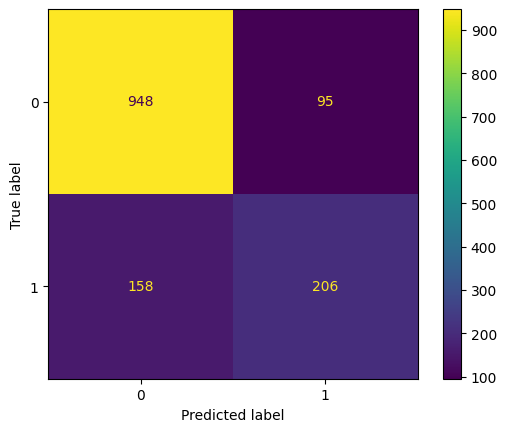

In [752]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_lr)
plt.show()

In [753]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1043
           1       0.68      0.57      0.62       364

    accuracy                           0.82      1407
   macro avg       0.77      0.74      0.75      1407
weighted avg       0.81      0.82      0.81      1407



In [755]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
dt = DecisionTreeClassifier(random_state=46)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_leaf_nodes': [None, 10, 20, 30],
    'class_weight': [None, 'balanced']
}
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Parameters:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'max_leaf_nodes': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross Validation Accuracy:
0.7961245707519242


In [756]:
best_dt = grid_search.best_estimator_

y_pred_dt = best_dt.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7810945273631841

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1043
           1       0.58      0.57      0.57       364

    accuracy                           0.78      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407


Confusion Matrix
[[893 150]
 [158 206]]


In [757]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [758]:
rf_model = RandomForestClassifier(random_state=46)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

In [759]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


Accuracy : 0.7846481876332623
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1043
           1       0.61      0.47      0.53       364

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.78      1407

[[932 111]
 [192 172]]


In [760]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'class_weight': [None, 'balanced']
}

In [761]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=46),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=46), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [10, 20, None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=2)

In [762]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [763]:
print("Best CV Accuracy:")
print(grid_search.best_score_)

Best CV Accuracy:
0.8019891849220446


In [764]:
best_rf = grid_search.best_estimator_

y_pred_best_rf = best_rf.predict(x_test)

In [765]:
print("Accuracy :", accuracy_score(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))
print(confusion_matrix(y_test, y_pred_best_rf))

Accuracy : 0.8130774697938877
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1043
           1       0.68      0.53      0.59       364

    accuracy                           0.81      1407
   macro avg       0.76      0.72      0.74      1407
weighted avg       0.80      0.81      0.81      1407

[[951  92]
 [171 193]]


# Customer Churn Prediction using Machine Learning

## Objective

The objective of this project is to develop a machine learning model that predicts whether a customer is likely to churn (leave the telecommunications company). Early identification of customers who are likely to churn enables the company to implement customer retention strategies, improve customer satisfaction, and reduce revenue loss.

---

# Step 1: Importing Required Libraries

In this step, the required Python libraries were imported for data manipulation, visualization, preprocessing, machine learning model development, and evaluation.

Libraries used include:

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

These libraries provide functions for handling datasets, visualizing data, preprocessing features, training machine learning models, and evaluating their performance.

---

# Step 2: Loading the Dataset

The training and testing datasets were loaded into Pandas DataFrames.

After loading the data, the following functions were used:

- head()
- shape
- info()
- describe()

These functions helped in understanding the dataset structure, data types, number of observations, and statistical summary of numerical features.

---

# Step 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the characteristics of the dataset before preprocessing.

The following analyses were carried out:

### Dataset Overview

- Checked the number of rows and columns.
- Examined data types.
- Identified numerical and categorical features.

### Missing Value Analysis

Missing values were identified using:

```python
train.isnull().sum()
```

Missing values were found in:

- Gender
- OnlineSecurity
- MonthlyCharges
- TotalCharges

### Duplicate Analysis

Duplicate records were checked using:

```python
train.duplicated().sum()
```

Duplicate Customer IDs were also verified.

### Target Variable Analysis

The distribution of the target variable (Churn) was analyzed using count plots to determine whether the dataset was balanced or imbalanced.

### Numerical Feature Analysis

The following numerical features were analyzed:

- Tenure
- MonthlyCharges
- TotalCharges

Histograms, boxplots, and skewness values were used to study their distributions.

### Categorical Feature Analysis

Count plots were used to visualize the distribution of categorical variables such as:

- Gender
- InternetService
- Contract
- PaymentMethod
- Partner
- PhoneService

### Correlation Analysis

A correlation matrix was generated to identify relationships among numerical variables.

### Outlier Detection

Outliers were detected using the Interquartile Range (IQR) method.

---

# Step 4: Data Preprocessing

Data preprocessing was performed to prepare the dataset for machine learning.

## Missing Value Treatment

Missing values were handled as follows:

| Feature | Method Used |
|----------|-------------|
| Gender | Mode Imputation |
| OnlineSecurity | Mode Imputation |
| MonthlyCharges | Median Imputation |
| TotalCharges | Median Imputation |

The median was used for numerical variables because it is less sensitive to skewed distributions than the mean.

---

## Data Type Conversion

Numerical columns stored as object data types were converted into numeric data types.

---

## Outlier Treatment

Outliers were handled using the IQR method.

The following steps were performed:

- Calculated Q1 and Q3
- Computed the Interquartile Range (IQR)
- Determined lower and upper limits
- Capped extreme values using the calculated limits

This reduces the influence of extreme observations while preserving most of the data.

---

## Encoding

Machine learning algorithms require numerical input. Therefore categorical variables were encoded.

### Binary Encoding

Binary encoding was applied to:

- Gender
- Partner
- Dependents
- PhoneService
- PaperlessBilling
- Churn

Example:

- Yes → 1
- No → 0

### One-Hot Encoding

One-Hot Encoding was applied to:

- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaymentMethod

One-Hot Encoding was selected because these variables have multiple categories without any natural ordering.

---

## Feature Scaling

Feature scaling was performed using **StandardScaler**.

The following numerical features were scaled:

- Tenure
- MonthlyCharges
- TotalCharges

StandardScaler transforms the data so that each feature has a mean of zero and a standard deviation of one. This improves the performance of algorithms such as Logistic Regression.

---

# Step 5: Model Development

Three machine learning classification models were developed.

## Logistic Regression

Logistic Regression is a linear classification algorithm used for binary classification problems.

Advantages:

- Simple to implement
- Fast training
- Easy to interpret
- Performs well on binary classification problems

---

## Decision Tree

Decision Tree is a supervised learning algorithm that splits the dataset into smaller subsets based on feature values.

Advantages:

- Easy to understand
- Captures nonlinear relationships
- Requires little data preparation

---

## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:

- Higher prediction accuracy
- Reduces overfitting
- More robust than a single Decision Tree
- Performs well on both numerical and categorical features

---

# Step 6: Hyperparameter Tuning

Hyperparameter tuning was performed using **GridSearchCV**.

The following models were tuned:

- Decision Tree
- Random Forest

GridSearchCV searches different combinations of hyperparameters using cross-validation and selects the combination that provides the best model performance.

---

# Step 7: Model Evaluation

The trained models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

These metrics provide a comprehensive evaluation of classification performance.

---

# Recommended Model

Among the three models developed:

- Logistic Regression
- Decision Tree
- Random Forest

**Random Forest is recommended** for this customer churn prediction problem because:

- It generally achieves higher predictive accuracy than a single Decision Tree.
- It reduces overfitting by combining multiple decision trees.
- It handles both numerical and categorical features effectively.
- It is robust to noise and outliers.
- It can model complex relationships between customer characteristics and churn.

If the tuned Random Forest model achieves the highest Accuracy and F1-score among the evaluated models, it should be selected as the final model.

If Logistic Regression performs similarly, it can also be considered because it provides excellent interpretability. However, for most customer churn datasets, Random Forest typically offers better predictive performance.

---

# Conclusion

A complete machine learning pipeline was implemented for customer churn prediction.

The project included:

- Data loading
- Exploratory Data Analysis
- Missing value treatment
- Outlier handling
- Encoding
- Feature scaling
- Model building
- Hyperparameter tuning
- Model evaluation

The developed model can help telecommunication companies identify customers who are likely to churn, allowing them to implement targeted retention strategies and improve customer loyalty.